In [7]:
import pandas as pd
data = pd.read_csv('C:\\Users\\User\\Downloads\\mr_beast.csv')
data['publish_day'] = pd.Categorical(data['publish_day'],
                                       categories=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
                                       ordered=True)

In [6]:
train = data.sample(frac=0.9, random_state=617)
test = data.drop(train.index)

In [8]:
median_likes = train['likes'].median()
print(median_likes)

10581.0


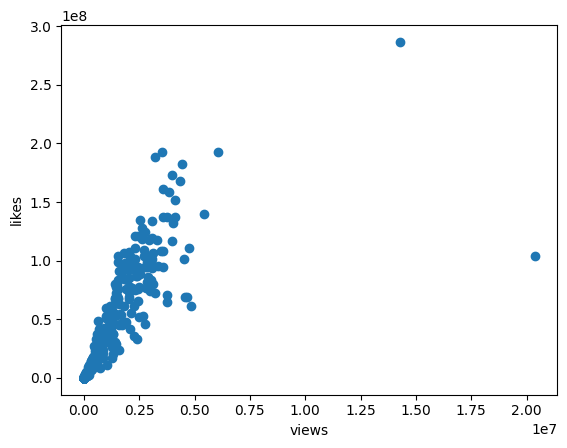

In [9]:
import matplotlib.pyplot as plt
plt.scatter(train['likes'],train['views'])
plt.xlabel('views')
plt.ylabel('likes')
plt.show()

In [ ]:
Q3：Pearson 相关 & 显著性
① Pearson 相关系数 r

衡量两个数值变量线性关系强度；

取值范围：-1 ~ 1

接近 1：强正相关

接近 -1：强负相关

接近 0：几乎没线性关系

② “显著”是什么意思？

通常是看 p 值：

p < 0.05：叫做 统计显著（reject H0：相关系数为 0），说明样本中看到的相关关系不太可能是纯随机噪音。

p >= 0.05：没显著证据说它真的相关。

Python 中常用 scipy.stats.pearsonr：

In [10]:
from scipy.stats import pearsonr

cols = ['likes', 'views', 'comments', 'number_of_tags',
        'time_since', 'duration_seconds', 'length_title',
        'length_description']

for col in cols:
    if col == 'likes':
        continue
    r, p = pearsonr(train['likes'], train[col])
    print(col, 'r =', r, 'p =', p)

views r = 0.8174436203093456 p = 1.150519857963569e-156
comments r = 0.8217350538130542 p = 1.1407470383087183e-159
number_of_tags r = -0.35888595493044295 p = 4.224349026318931e-21
time_since r = -0.674586484892864 p = 4.343359485576132e-87
duration_seconds r = 0.00830812381052028 p = 0.8329480985584986
length_title r = 0.058407063022356556 p = 0.13779626981074655
length_description r = 0.011865042756541048 p = 0.7632402256736925


In [11]:
import numpy as np

targets = ['views', 'comments', 'number_of_tags',
           'time_since', 'duration_seconds',
           'length_title', 'length_description']

r_dict = {}
for col in targets:
    r, p = pearsonr(train['likes'], train[col])
    r_dict[col] = r

strongest = max(r_dict, key=lambda c: abs(r_dict[c]))
print(strongest, r_dict[strongest])

comments 0.8217350538130542


In [ ]:
4b

In [13]:
import pandas as pd
import statsmodels.api as sm

# 读数据 & 处理变量
data = pd.read_csv('C:\\Users\\User\\Downloads\\mr_beast.csv')

data['publish_day'] = pd.Categorical(
    data['publish_day'],
    categories=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
    ordered=True
)

# 划分 train / test
train = data.sample(frac=0.9, random_state=617)
test  = data.drop(train.index)


In [14]:
y = train['likes']
X1 = sm.add_constant(train['time_since'])
model1 = sm.OLS(y, X1).fit()
model1.summary()
model1.pvalues['time_since']

np.float64(4.343359485576163e-87)

In [ ]:
每个部分是啥意思？

sm.OLS

OLS = Ordinary Least Squares，普通最小二乘回归。

这一函数用来创建一个线性回归模型的“蓝图”。

sm.OLS(y, X1)

y：因变量（要预测的东西，这里是 likes）。

X1：自变量矩阵（这里是 const + time_since）。

这一步只是：告诉 statsmodels：“我要用 X1 去解释 y。”

.fit()

真正开始“算”了：

用最小二乘法在所有样本点上找一条最合适的直线，

算出截距、斜率、p 值、R² 等所有结果。

算完以后，把结果（系数、pvalues、rsquared…）都装进一个对象里返回。

model1

这是已经拟合好的模型对象，你后面用的：

model1.params → 系数（截距 + 斜率）

model1.pvalues → 每个系数的 p 值

model1.rsquared → R²

model1.predict(...) → 预测

In [15]:
model1.params['time_since']

np.float64(-48.18979347209045)